In [ ]:
!gdown  https://drive.google.com/uc?id=1ouSOru91p-ZJCyI6E8cGh7N0r3vffi06 -O AudioMNIST.zip
!unzip AudioMNIST.zip

Pipeline = AudioDataset (__init__ paths, __getitem__ return wavform, label) -> EDA -> Train\Test Dataloaders with collators -> Featurizer(batch): model input -> LSTM model -> Train Model func

# Audio Dataset

In [ ]:
from torch.utils.data import Dataset, Subset, DataLoader
from pathlib import Path

import librosa
import librosa.display
from IPython.display import Audio
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np



import torch

sns.set_theme(style='whitegrid', palette='bright')

In [ ]:
class AudioDataset(Dataset):
    def __init__(self, path_to_data):
        self.paths = list(map(str, Path(path_to_data).glob('**/*.wav')))
        self.labels = list(map(lambda x: int(Path(x).name.split('_')[0]), self.paths))

    def __getitem__(self, index):
        wav, sr = librosa.load(self.paths[index])
        label = self.labels[index]

        return torch.tensor(wav, dtype=torch.float), label

    def __len__(self):
        return len(self.paths)

In [ ]:
dataset = AudioDataset('/content/AudioMNIST')

In [ ]:
def show_waveform(wav, label, sr=22050):
    # plt.figure(figsize=(11, 8))

    librosa.display.waveshow(np.array(wav), sr=sr)
    plt.ylabel('Амплитуда')
    plt.xlabel('Время')
    plt.title(label)

    plt.show()

def show_spectrogram(wav, label, sr=22050):
    # plt.figure(figsize=(11, 8))

    spectrogram = librosa.stft(np.array(wav), n_fft=2048)
    spectrogram = librosa.amplitude_to_db(abs(spectrogram))

    plt.title(label)
    librosa.display.specshow(spectrogram, sr=sr, x_axis='time', y_axis='hz', n_fft=2048)

    plt.ylabel('Частота')
    plt.xlabel('Окно STFT')

    plt.colorbar()
    plt.show()

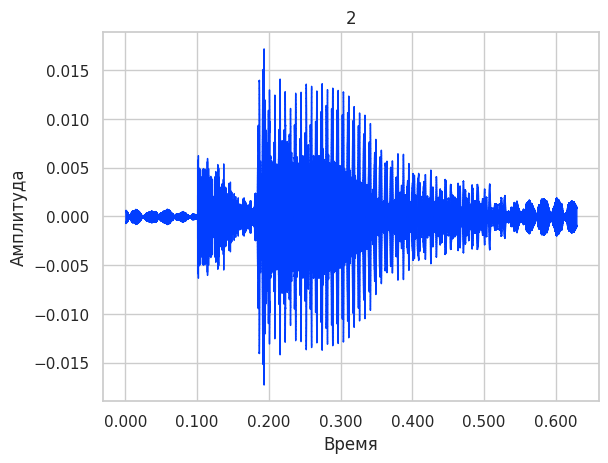

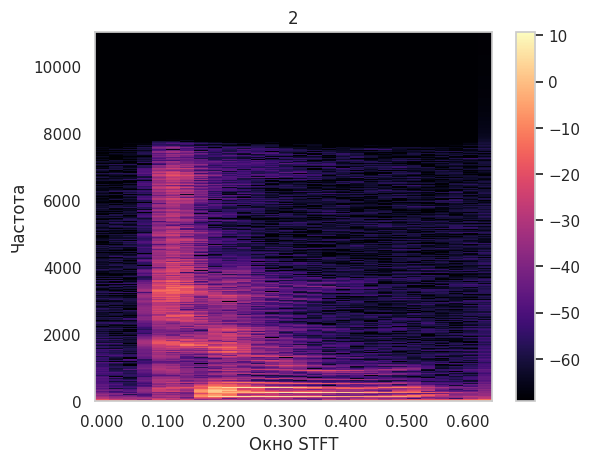

In [ ]:
show_waveform(dataset[1][0], dataset[1][1])
show_spectrogram(dataset[1][0], dataset[1][1])
Audio(dataset.paths[1])

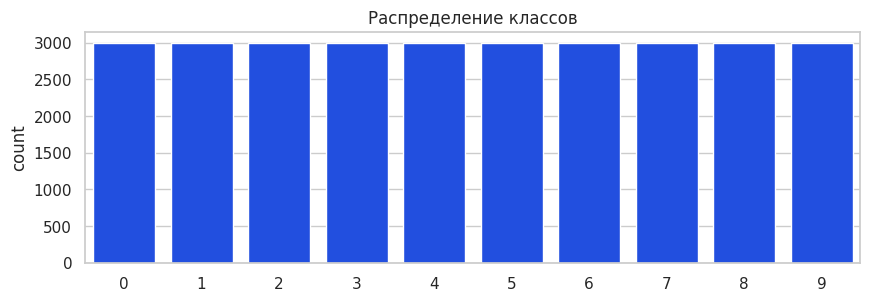

In [ ]:
plt.figure(figsize=(10, 3))

plt.title('Распределение классов')
sns.countplot(x=dataset.labels)

plt.show()

In [ ]:
class PadCollator:
    def __call__(self, batch):
        lengths = []
        wavs, labels = zip(*batch)

        for wav in wavs:
            lengths.append(len(wav))

        max_len = max(lengths)

        padded_batch = torch.zeros(len(batch), max_len)

        for idx in range(len(batch)):
            padded_batch[idx, :lengths[idx]] = wavs[idx]


        lengths = torch.tensor(lengths, dtype=torch.int)
        labels = torch.tensor(labels, dtype=torch.int)

        return {
            'wavs': padded_batch,
            'labels': labels,
            'lengths': lengths
        }

In [ ]:
train_ratio = 0.8
val_ratio = 1 - train_ratio

inds = torch.randperm(len(dataset))
train_inds = inds[:int(len(dataset) * train_ratio)]
val_inds = inds[int(len(dataset) * train_ratio):]

train_dataset = Subset(dataset, train_inds)
val_dataset = Subset(dataset, val_inds)

In [ ]:
assert not set(train_inds.tolist()).intersection(set(val_inds.tolist())), 'Пересечение!'

In [ ]:
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=32,
                              shuffle=True,
                              collate_fn=PadCollator())

val_dataloader = DataLoader(dataset=val_dataset,
                            batch_size=32,
                            shuffle=False,
                            collate_fn=PadCollator())

In [ ]:
print(next(iter(train_dataloader)))
print(next(iter(train_dataloader))['wavs'].shape) #(batch_size, time_size)

{'wavs': tensor([[-2.0838e-04, -3.2752e-04, -3.1671e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-9.0959e-05, -1.5197e-04, -1.3054e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-1.4890e-04, -2.3891e-04, -2.2035e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [ 2.9372e-04,  4.9176e-04,  5.1786e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 9.2239e-05,  1.5050e-04,  1.3200e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 5.3158e-04,  8.5476e-04,  8.5792e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]]), 'labels': tensor([0, 6, 6, 4, 9, 5, 3, 0, 2, 8, 1, 8, 6, 7, 4, 4, 3, 8, 8, 6, 6, 4, 9, 4,
        5, 1, 0, 7, 6, 6, 4, 8], dtype=torch.int32), 'lengths': tensor([15087, 17070, 19715, 12032, 15435, 13849, 16553, 13481, 10101, 11378,
        10398, 13324, 13847, 18673, 14912, 13775, 12346, 11232, 14480, 15081,
        17612, 11112, 13618, 14363, 18059, 20507

In [ ]:
class Featurizer(nn.Module):
    def __init__(self):
        super(Featurizer, self).__init__()

        self.featurizer = torchaudio.transforms.MelSpectrogram(
            sample_rate=16_000,
            n_fft=1024,      # размер FFT (также определяет padding при center=True)
            win_length=1024, # длина окна STFT в сэмплах
            hop_length=256,  # шаг сдвига окна (stride)
            n_mels=64,
            center=True      # добавляется padding n_fft//2 слева и справа
        )

    def forward(self, wav, length=None):
        # wav: (B, T) или (T,)
        # На выходе: (B, n_mels, time_frames)
        mel_spectrogram = self.featurizer(wav)

        # clamp(min=1e-5):
        # В mel-спектрограмме лежат мощности (энергии), они могут быть очень близки к 0.
        # Логарифм от 0 = -inf → появятся NaN / -inf в тензоре.
        # Поэтому мы "поджимаем" минимальное значение к 1e-5.
        mel_spectrogram = mel_spectrogram.clamp(min=1e-5).log()

        # log():
        # 1) Переводим спектр в лог-шкалу (похоже на dB-шкалу)
        # 2) Это ближе к тому, как человек воспринимает звук (логарифмически)
        # 3) Сжимает динамический диапазон → обучение становится стабильнее

        if length is not None:
            # Считаем количество временных фреймов после STFT

            # Базовая формула без паддинга:
            # T = floor((L - win_length) / hop_length) + 1
            #
            # Делим на hop_length, потому что окно сдвигается именно на этот шаг.
            # Это фактически количество "шагов" окна по сигналу.
            length = (length - self.featurizer.win_length) // self.featurizer.hop_length

            # +1 — потому что количество окон = количество сдвигов + первое окно
            # +4 — из-за center=True:
            # MelSpectrogram добавляет padding n_fft//2 слева и справа.
            # При n_fft=1024 и hop=256 это даёт 1024 / 256 = 4 дополнительных фрейма.
            length += 1 + 4

            return mel_spectrogram, length

        return mel_spectrogram